# Chapter 3. 회귀 알고리즘과 모델 규제
---

## 03-1. k-최근접 이웃 회귀
---


이제 우리에게 주어진 문제는 다음과 같다.<br>
업계 최초로 농어를 무게 단위로 판매하려고 하는데, 공급처에서 생선 무게를 잘못 측정해서 보낸 것이다.<br>
<br>
즉, 우리는 현재 농어의 길이, 높이, 두께 등의 데이터를 이용해서 농어의 무게를 예측할 수 있어야 하는 것이다.<br>
&rArr; 이러한 문제를 우리는 **회귀(Regression)**이라고 한다.

--- 
### k-최근접 이웃 회귀
지도 학습 알고리즘은 다음과 같이 나뉜다:
- 분류(분류는 우리가 2장까지 다루었다.)
- **회귀(Regression)**
    &rArr; 회귀는 클래스 중 하나로 분류하는 것이 아니라, 임의의 어떤 숫자를 예측하는 문제이다<br>
    Ex. 내년도 경제 성장률 예측, 배달 도착 시간 예측 등

<br>
"k-최근접 이웃" 알고리즘은 분류와 회귀에 둘 다 적용될 수 있다.

- 분류에서는 다음과 같이 적용된다.
    1) 예측하려는 샘플에 "가장 가까운" 샘플 k개를 선택한다.
    2) 그 샘플들의 클래스를 확인하여 "다수 클래스"를 새로운 샘플의 클래스로 예측한다.

- 회귀에서는 다음과 같다.
    1) 분류와 동일하게 가장 가까운 샘플 k개를 선택한다.
    2) 여기서 회귀이기 때문에 클래스가 아닌 "수치"에 집중한다.
      &rArr; 해당 수치들의 평균을 이용하여 구한다.

---

### 데이터 준비

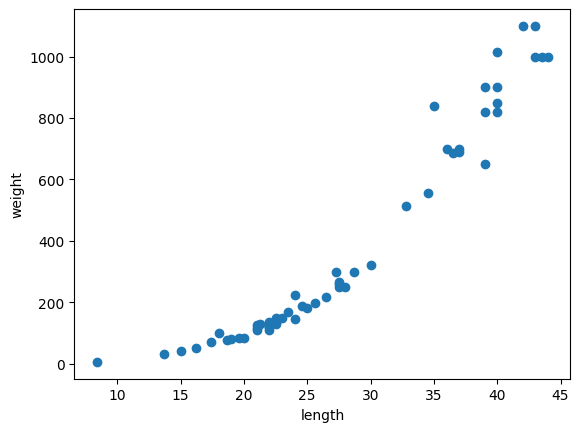

In [1]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

# 먼저 해당 데이터들에 대한 산점도를 그려본다
import matplotlib.pyplot as plt

plt.scatter(perch_length, perch_weight)

plt.xlabel("length")
plt.ylabel("weight")

plt.show()

In [ ]:
# 위에서 농어의 길이가 커질수록 무게도 무거워진다는 것을 확인했다. (확인하지 않아도 자명하지만...)
# 이제는 훈련 세트와 테스트 세트로 데이터를 나눈다.
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    perch_length,
    perch_weight,
    random_state=42
) 

print(train_input)
print(test_input)

[19.6 22.  18.7 17.4 36.  25.  40.  39.  43.  22.  20.  22.  24.  27.5
 43.  40.  24.  21.  27.5 40.  32.8 26.5 36.5 13.7 22.7 15.  37.  35.
 28.7 23.5 39.  21.  23.  22.  44.  22.5 19.  37.  22.  25.6 42.  34.5]
(42,)
[ 8.4 18.  27.5 21.3 22.5 40.  30.  24.6 39.  21.  43.5 16.2 28.  27.3]


사이킷런에 사용할 훈련 세트는 2차원 배열이어야 한다.\
근데 `perch_length`가 1차원 배열이기 때문에 이를 나눈 `train_input`, `train_target` 모두 1차ㅜ원 배열이다.\
<br>

즉, 우리는 1차원 배열을 1개의 열이 있는 2차원 배열로 바꿔야 한다.\
이를 위해 넘파이 배열의 크기를 바꿀 수 있는 `shape()`을 사용한다.

In [ ]:
test_array = np.array([1, 2, 3, 4])
print(test_array.shape) # (4,) => 파이썬에서 1차원 배열의 크기는 원소가 1개인 튜플로 나타난다.

test_array = test_array.reshape(2, 2)
print(test_array.shape) # (2, 2)

# 단, 바꾸려고 지정한 크기와 원본 배열의 원소 개수가 다르면 에러가 발생한다.
# test_array = test_array.reshape(2, 3) # ValueError: cannot reshape array of size 4 into shape (2,3)

(4,)
(2, 2)


In [ ]:
# 이제 train_input 과 test_input의 크기를 바꿔본다.
print(train_input.shape, test_input.shape)

# train_input = train_input.reshape(42, 1)
# test_input = test_input.reshape(14, 1)

# 넘파이에서는 배열의 크기를 자동으로 지정하는 기능이 존재한다.
# 크기에 -1을 지정하면, 다른 차원을 채우고 남은 원소에 맞게 차원을 지정하라는 것을 의미한다.
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

print(train_input)
print(test_input)

(42, 1) (14, 1)
[[19.6]
 [22. ]
 [18.7]
 [17.4]
 [36. ]
 [25. ]
 [40. ]
 [39. ]
 [43. ]
 [22. ]
 [20. ]
 [22. ]
 [24. ]
 [27.5]
 [43. ]
 [40. ]
 [24. ]
 [21. ]
 [27.5]
 [40. ]
 [32.8]
 [26.5]
 [36.5]
 [13.7]
 [22.7]
 [15. ]
 [37. ]
 [35. ]
 [28.7]
 [23.5]
 [39. ]
 [21. ]
 [23. ]
 [22. ]
 [44. ]
 [22.5]
 [19. ]
 [37. ]
 [22. ]
 [25.6]
 [42. ]
 [34.5]]
[[ 8.4]
 [18. ]
 [27.5]
 [21.3]
 [22.5]
 [40. ]
 [30. ]
 [24.6]
 [39. ]
 [21. ]
 [43.5]
 [16.2]
 [28. ]
 [27.3]]


---

### 결정계수

사이킷런에서 K-최근접 이웃 회귀 알고리즘을 구현한 클래스는 `KNeighborsRegressor` 이다.\
(사용법은 `KNeighborsClassifier`과 유사하다.)

In [19]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor()

# 모델 훈련
knr.fit(train_input, train_target)

# 평가
print(knr.score(test_input, test_target))

0.992809406101064


위의 모델 평가에서 나온 점수는 뭘 의미하는 걸까?\
<br>

- 분류의 경우에는, 테스트 세트에 있는 샘플을 정확하게 분류한 개수의 비율이다. (쉽게 말해 정답을 맞힌 개수의 비율이다.)\

- 하지만, 회귀의 경우에는 정확한 수치를 맞힌다는 것이 **불가능**하다. 예측하는 값, 타깃 모두 임의의 수치이기 때문
  - 조금 다른 값으로 평가를 하게 되는데, 이 점수를 **결정계수(cofficient of determination)** 라고 부른다.

$$
R^ 2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} = 1 - \frac{(타깃 - 예측)^2 의 합}{(타깃 - 평균)^2 의 합}
$$

- 만약 타깃의 평균 정도를 예측하는 수준이라면(즉, 분자와 분모가 비슷해져), 
  &rArr; 결정계수는 0에 가까워지고

- 예측이 타깃에 아주 가까워지면(분자가 0에 가까워지기 때문에), 1에 가까운 값이 된다.

<br>

직감적으로 얼마나 좋은지 이해하기 위해서 다른 값을 계산해보자.<br>
타깃과 예측한 값 사이의 차이를 구해 보면 어느 정도 예측이 벗어났는지 가능하기 좋다.<br>

&rArr; `mean_absolute_error()`는 타깃과 예측의 절대값 오차를 평균하여 반환한다.

In [20]:
from sklearn.metrics import mean_absolute_error

# 테스트 세트에 대한 예측을 만든다.
test_prediction = knr.predict(test_input)

# 테스트 세트에 대한 평균 절댓값 오차를 계산한다.
mae = mean_absolute_error(test_target, test_prediction)
print(mae)

19.157142857142862


해당 값은 결과에서 예측이 평균적으로 19g 정도 타깃값과 다르다는 것을 알려준다.

---

### 과대적합 vs 과소적합
지금까지는 테스트 세트로 모델을 평가해 왔다. 훈련 세트로 평가하면 어떻게 될까?<br>

In [21]:
print(knr.score(train_input, train_target))

0.9698823289099254


모델에서 훈련 세트와 테스트 세트에서 평가하면 두 값 중 어느 것이 더 높아야 하는건가?\
&rArr; 보통 훈련 세트에서 훈련을 진행했기 때문에, 훈련 세트에서의 점수가 조금 더 높게 나온다.

<br>

- 만약 훈련 세트에서 점수가 굉장히 좋았지만, 테스트 세트에서 점수는 낮다면\
  &rArr; 모델이 훈련 세트에 **과대적합(Overfitting)** 되었다고 한다.\
  &rArr; 즉, 훈련 세트에만 잘 맞는 모델이라 실전에 투입한 새로운 샘플에 대한 예측에 대해서 잘 동작하지 않은 것이다.

- 반대로 훈련 세트보다 테스트 세트의 점수가 높거나 두 점수가 모두 너무 낮은 경우는\
  &rArr; 모델이 훈련 세트에 **과소적합(Underfitting)** 되었다고 한다.\
  &rArr; 즉, 모델이 너무 단순하여 훈련 세트에 적절히 훈련되지 않은 경우다.\
        + 또는 훈련 세트와 테스트 세트의 크기가 매우 작은것도 또 다른 원인이 될 수 있다.

<br>

앞서 확인한 경우에는 훈련 세트보다 테스트 세트의 점수가 높으니 과소적합입니다.\
해당 문제의 해결을 위해서는 모델을 좀 더 복잡하게 만들어야 한다.\
&rArr; knn 알고리즘에서는 "이웃의 개수 k"를 줄이는 것이 그 방법이다.

In [22]:
# 이웃의 개수를 3으로 설정한다.
knr.n_neighbors = 3

# 다시 훈련
knr.fit(train_input, train_target)
print(knr.score(train_input, train_target))

0.9804899950518966


&rArr; 이로써 훈련 세트에 있는 국지적인 패턴에 민감해지게 되며,\
    반대로 늘리게 되면 데이터 전반에 있는 일반적인 패턴을 따르게 될 것이다.